<a href="https://colab.research.google.com/github/mariacastrom00/AI_exercises_MJCM/blob/main/Assignment2_AH2179_MJCM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 2 - Text classification for traffic sentimental analysis

By: Maria José Castro Moreno

Course: AH2179



Exercise: Use the text classification for traffic sentimental analysis. Develop more machine learning based text classification models for traffic sentimental analysis and tune the model parameters to achieve the best performance. The machine learning based text classification models you may develop include logistic regression, KNN, RF, XGBoost, SVM, and Naïve Bayes models.


**Assignment task**:
Find the best text classification model for the sentimental analysis (assignment submission)
* Identify which vectorization method works the best or basically does not much difference.
* Identify which model, together with its corresponding hyperparameters, gives the best performance for traffic sentimental analysis.  


## Importing dataset and deleting duplicates

In [135]:
import pandas as pd
from statistics import mode
import numpy as np
import os

In [136]:
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/a1e354d42a1ae821b927f928b507b1a3cffe6012/Exercise_4_Text_classification/Pakistani%20Traffic%20sentiment%20Analysis.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Pakistani Traffic sentiment Analysis.csv')
df.head(10)

,Text,Sentiment
0,Adayala road is clear,0
1,Traffic jam from parbat rd to nazim-ud-din rd ...,1
2,Mandra is clear,0
3,Fort street is clear,0
4,"Mashriq Hotel towards Fawara Chowk, City Sadda...",1
5,Traffic jam from gulberg expy to margalla ave,1
6,Korang Rd road is free,0
7,Road open from Cantt Station to Lucky star,0
8,Zagid baig is clear,0
9,Traffic open from jaffar khan openali rd to se...,0


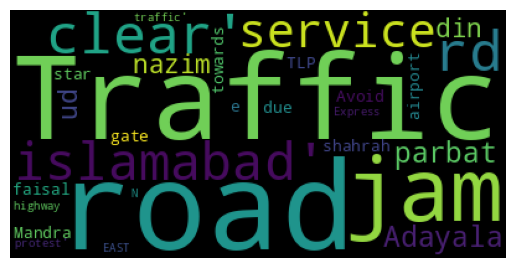

In [137]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text = df['Text'].values

wordcloud = WordCloud().generate(str(text))

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2109 entries, 0 to 2108
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Text       2109 non-null   object
 1   Sentiment  2109 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 33.1+ KB


In [139]:
# Displaying the instances of each class
df.groupby('Sentiment').describe()

# Delete the duplicate rows
df = df.drop_duplicates()

# Displaying the instances of each class
df.groupby('Sentiment').describe()

Text                                          
          count unique                           top freq
Sentiment                                                
0          1008   1008           I8 is clear at 8 am    1
1          1079   1079  Express highway have traffic    1

In [140]:
# Convert the text to vectorizer
x = df['Text']

# Obtain the label
y = df['Sentiment']

## Splitting the dataset

In [141]:
# 80/20 split
from sklearn.model_selection import train_test_split

# Split the train and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0, stratify=y)

Creating the CountVectorizer instance, the ngram_range represents the length range of phrase segmentation,the stop_words parameter is set to "english" to remove common English stop words like "and", "the", and "a", min_df is to serve as a threshold to delete some words which have a frequency lower then min_df.

In [142]:
from sklearn.feature_extraction.text import CountVectorizer


vectorizer = CountVectorizer(ngram_range=(1, 2), stop_words='english', min_df=20)

x_train_vectorized = vectorizer.fit_transform(x_train)
x_test_vectorized = vectorizer.transform(x_test)

Training the classifier. LogisticRegression class is used (Logistic regression to fit a model to the data).

In [143]:
from sklearn.linear_model import LogisticRegression

# Creating the model, maximal iterations 1000, random number generator.
model = LogisticRegression(max_iter=1000, random_state=0)

# Trains the logistic regression model using the training data.
model.fit(x_train_vectorized, y_train)

LogisticRegression(max_iter=1000, random_state=0)

The accuracy of the model is: 0.9641148325358851


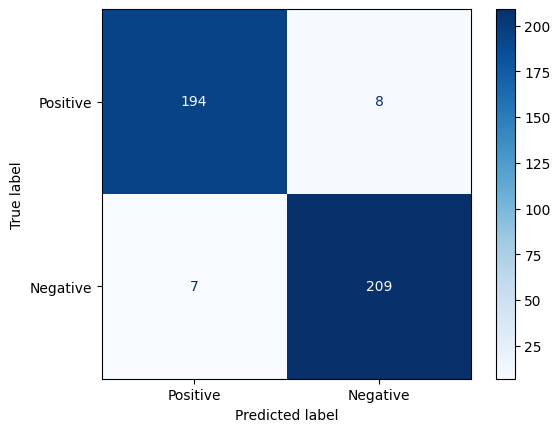

In [144]:
%matplotlib inline
from sklearn.metrics import ConfusionMatrixDisplay as cmd
from sklearn.metrics import accuracy_score

# Show the results in a confusion matrix
cmd.from_estimator(model, x_test_vectorized, y_test, display_labels=['Positive','Negative'], cmap='Blues')

# Calculate accuracy
print('The accuracy of the model is: ' + str(accuracy_score(y_test, model.predict(x_test_vectorized))))

## Performance of different text vectorization methods

Method 1: CountVectorizer

Method 2: HashingVectorizer

Method 3: TfidfVectorizer

In [145]:
from sklearn.feature_extraction.text import CountVectorizer

# Vectorization method 1: CountVectorizer
#vectorizer = CountVectorizer(
#    ngram_range=(1, 2),
#    stop_words='english',
#    min_df=20)

#vectorizer_name = 'CountVectorizer'

In [146]:
from sklearn.feature_extraction.text import HashingVectorizer

# Vectorization method 2: HashingVectorizer
#vectorizer = HashingVectorizer(
#    ngram_range=(1, 2),
#    n_features=200,
#    stop_words='english')

#vectorizer_name = 'HashingVectorizer'

In [147]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorization method 3: TfidfVectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words='english',
    min_df=20)

vectorizer_name = 'TfidfVectorizer'

## Testing the different models depending on vectorization method

Method 1: Logistic Regression

Method 2: K Neighbors Classifier

Method 3: Random Forest

Method 4: XGBoost

Method 5: SVM

Method 6: Naïve Bayes

In [148]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
%matplotlib inline
from sklearn.metrics import ConfusionMatrixDisplay as cmd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
import os

# Grid search used to find the best hyperparameters
# 5-cross valida
from sklearn.model_selection import GridSearchCV

# split into train/test set
x = df['Text']
y = df['Sentiment']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0, stratify=y)

# apply the vectorizers
x_train_vectorized = vectorizer.fit_transform(x_train)
x_test_vectorized = vectorizer.transform(x_test)

Best model parameter

In [149]:
results = []

In [150]:
# Model parameter 1: Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=0)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

grid_search.fit(x_train_vectorized, y_train)

best_lr = grid_search.best_estimator_

test_accuracy = accuracy_score(y_test, best_lr.predict(x_test_vectorized))

results.append({'Vectorizer': vectorizer_name,
    'Model': 'Logistic Regression',
    'Best Parameters': grid_search.best_params_,
    'CV Accuracy': grid_search.best_score_,
    'Test Accuracy': test_accuracy})

print("Best parameters:", grid_search.best_params_)
print("CV accuracy:", grid_search.best_score_)
print("Test accuracy:", test_accuracy)

Best parameters: {'C': 1}
CV accuracy: 0.9520670370969773
Test accuracy: 0.9617224880382775


In [151]:
# Model parameter 2: K Neighbors Classifier
model=KNeighborsClassifier()
param_grid = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

grid_search.fit(x_train_vectorized, y_train)

best_knn = grid_search.best_estimator_

test_accuracy = accuracy_score(y_test, best_knn.predict(x_test_vectorized))

results.append({'Vectorizer': vectorizer_name,
    'Model': 'KNN',
    'Best Parameters': grid_search.best_params_,
    'CV Accuracy': grid_search.best_score_,
    'Test Accuracy': test_accuracy})

print("Best parameters:", grid_search.best_params_)
print("CV accuracy:", grid_search.best_score_)
print("Test accuracy:", test_accuracy)

Best parameters: {'n_neighbors': 9, 'weights': 'distance'}
CV accuracy: 0.9221017424610238
Test accuracy: 0.930622009569378


In [152]:
# Model parameter 3: Random Forest
model = RandomForestClassifier(random_state=0)
param_grid = {'n_estimators': [100, 200, 300],
     'max_depth': [None, 10, 20, 30],
     'min_samples_split': [2, 5, 10],
     'min_samples_leaf': [1, 2, 4]}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

grid_search.fit(x_train_vectorized, y_train)

best_rf = grid_search.best_estimator_

test_accuracy = accuracy_score(y_test, best_rf.predict(x_test_vectorized))

results.append({'Vectorizer': vectorizer_name,
    'Model': 'Random Forest',
    'Best Parameters': grid_search.best_params_,
    'CV Accuracy': grid_search.best_score_,
    'Test Accuracy': test_accuracy})

print("Best parameters:", grid_search.best_params_)
print("CV accuracy:", grid_search.best_score_)
print("Test accuracy:", test_accuracy)

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
CV accuracy: 0.9616532700365037
Test accuracy: 0.9545454545454546


In [153]:
# Model parameter 4: XGBoost
model =  XGBClassifier()

param_grid = {'learning_rate': [0.01, 0.1, 0.2],
              'n_estimators': [100, 200, 300],
              'max_depth': [3, 4, 5]}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

grid_search.fit(x_train_vectorized, y_train)

best_xgb = grid_search.best_estimator_

test_accuracy = accuracy_score(y_test, best_xgb.predict(x_test_vectorized))

results.append({'Vectorizer': vectorizer_name,
    'Model': 'XGBoost',
    'Best Parameters': grid_search.best_params_,
    'CV Accuracy': grid_search.best_score_,
    'Test Accuracy': test_accuracy})

print("Best parameters:", grid_search.best_params_)
print("CV accuracy:", grid_search.best_score_)
print("Test accuracy:", test_accuracy)

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
CV accuracy: 0.9604556652460843
Test accuracy: 0.9497607655502392


In [154]:
# Model parameter 5: SVM
model = SVC(probability=True)
param_grid = {'kernel': ['linear', 'rbf', 'poly'],'C': [0.1, 1, 10]}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

grid_search.fit(x_train_vectorized, y_train)

best_svm = grid_search.best_estimator_

test_accuracy = accuracy_score(y_test, best_svm.predict(x_test_vectorized))

results.append({'Vectorizer': vectorizer_name,
    'Model': 'SVM',
    'Best Parameters': grid_search.best_params_,
    'CV Accuracy': grid_search.best_score_,
    'Test Accuracy': test_accuracy})

print("Best parameters:", grid_search.best_params_)
print("CV accuracy:", grid_search.best_score_)
print("Test accuracy:", test_accuracy)


Best parameters: {'C': 1, 'kernel': 'rbf'}
CV accuracy: 0.953865242487997
Test accuracy: 0.9593301435406698


In [155]:
# Model parameter 6: Naïve Bayes models
model=BernoulliNB()
param_grid = {'alpha': [0.01, 0.1, 0.5, 1, 2],'force_alpha': [True,False]}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

grid_search.fit(x_train_vectorized, y_train)

best_bnb = grid_search.best_estimator_

test_accuracy = accuracy_score(y_test, best_bnb.predict(x_test_vectorized))

results.append({'Vectorizer': vectorizer_name,
    'Model': 'Naive Bayes',
    'Best Parameters': grid_search.best_params_,
    'CV Accuracy': grid_search.best_score_,
    'Test Accuracy': test_accuracy})

print("Best parameters:", grid_search.best_params_)
print("CV accuracy:", grid_search.best_score_)
print("Test accuracy:", test_accuracy)

Best parameters: {'alpha': 0.01, 'force_alpha': True}
CV accuracy: 0.9418802035568502
Test accuracy: 0.9401913875598086


In [156]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='CV Accuracy',
    ascending=False
)

results_df

,Vectorizer,Model,Best Parameters,CV Accuracy,Test Accuracy
2,TfidfVectorizer,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.961653,0.954545
3,TfidfVectorizer,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.960456,0.949761
4,TfidfVectorizer,SVM,"{'C': 1, 'kernel': 'rbf'}",0.953865,0.959330
0,TfidfVectorizer,Logistic Regression,{'C': 1},0.952067,0.961722
5,TfidfVectorizer,Naive Bayes,"{'alpha': 0.01, 'force_alpha': True}",0.941880,0.940191
1,TfidfVectorizer,KNN,"{'n_neighbors': 9, 'weights': 'distance'}",0.922102,0.930622


## Confusion matrix

---

Only for the best performing model.

The test accuracy of the best model is: 0.9617224880382775


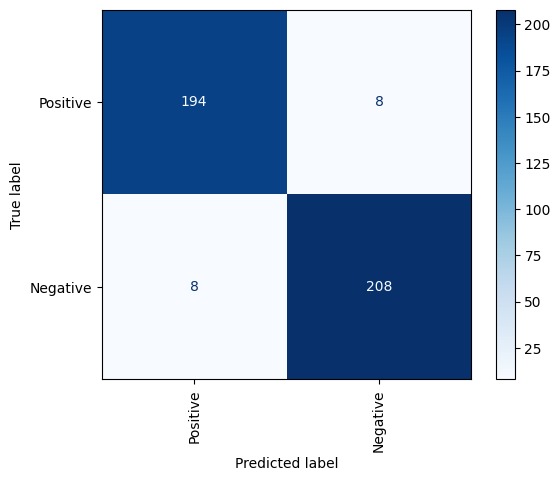

In [157]:
# Already imported ConfusionMatrixDisplay and accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

# Best-performing model
# best_lr, best_knn, best_rf, best_xgb, best_svm, best_bnb
best_model = best_lr

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_model,
    x_test_vectorized,
    y_test,
    display_labels=['Positive', 'Negative'],
    cmap='Blues',
    xticks_rotation='vertical')

# Calculate test accuracy
test_accuracy = accuracy_score(y_test, best_model.predict(x_test_vectorized))

print("The test accuracy of the best model is:", test_accuracy)

In [158]:
# Here you change the reviews
text = 'Adayala road is clear'

# Make a prediction for this review
# Best model is written in the cell above, change when trying the new ones
score = best_model.predict_proba(vectorizer.transform([text]))[0][1]

if score >0.5:
  attitude='negative'
else:
  attitude='positive'

print('The prediction result of this review is: '+ attitude)

The prediction result of this review is: positive
